In [8]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/Users/shahil/Documents/UCSB/2025-2026/PSTAT135/pstat135-nyc-taxi-4db0653d3d93.json"

Sending query to the legacy BigQuery dataset...
Sample shape successfully loaded: (200000, 11)
       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
count     200000.000000    200000.000000      200000.000000     200000.000000   
mean         -73.978585        40.755510         -73.978232         40.755902   
std            0.019295         0.022851           0.019570          0.023165   
min          -74.247864        40.570961         -74.247864         40.571228   
25%          -73.991135        40.740849         -73.991272         40.740543   
50%          -73.981407        40.756439         -73.980522         40.756437   
75%          -73.966858        40.770840         -73.966070         40.772148   
max          -73.723221        40.896618         -73.723549         40.896065   

       trip_distance    fare_amount  passenger_count  pickup_hour  pickup_dow  
count  200000.000000  200000.000000         200000.0     200000.0    200000.0  
mean        0.7

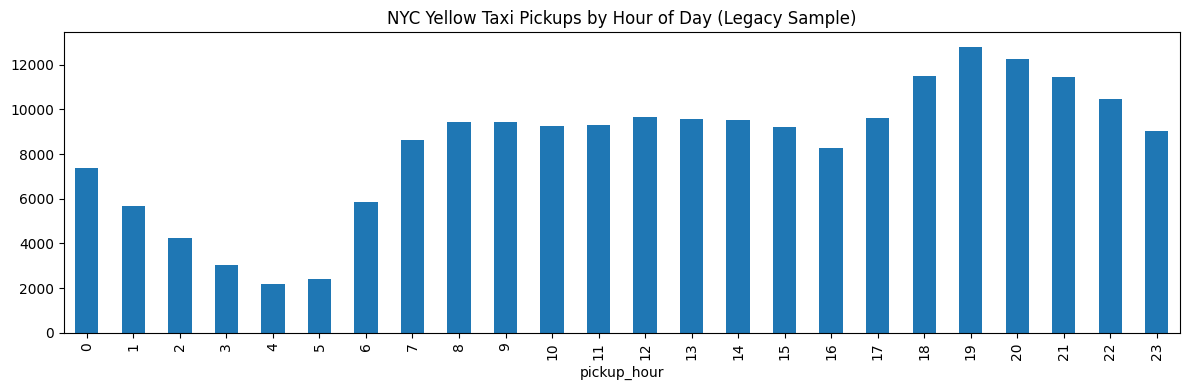

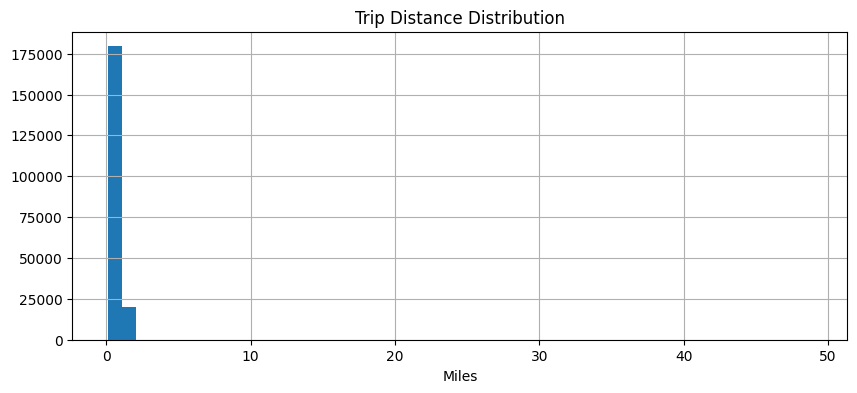

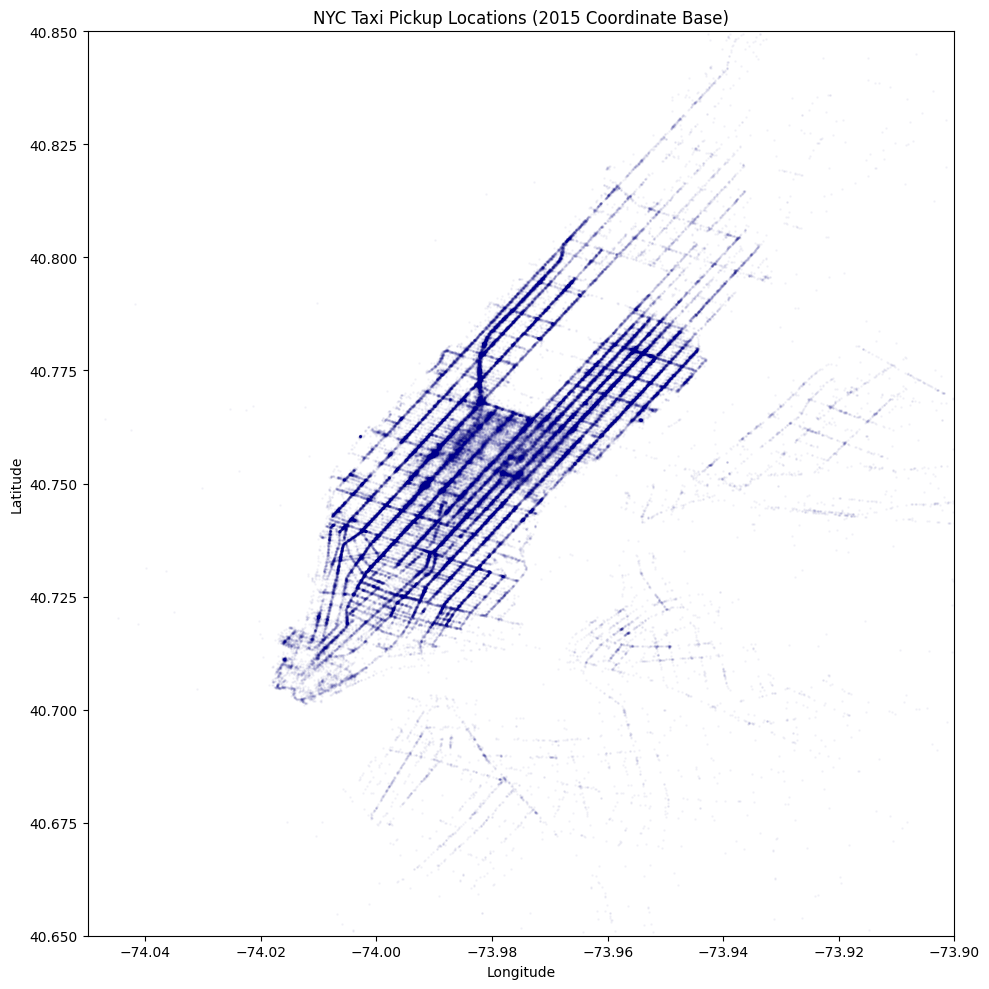

In [9]:
# 01_bigquery_eda.ipynb
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client = bigquery.Client(project="pstat135-nyc-taxi")

# Direct the query path to the legacy new_york dataset to guarantee raw coordinates
query = """
SELECT
  pickup_datetime,
  dropoff_datetime,
  pickup_longitude,
  pickup_latitude,
  dropoff_longitude,
  dropoff_latitude,
  trip_distance,
  fare_amount,
  passenger_count,
  EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
  EXTRACT(DAYOFWEEK FROM pickup_datetime) AS pickup_dow
FROM `bigquery-public-data.new_york.tlc_yellow_trips_2015`
WHERE
  pickup_latitude BETWEEN 40.5 AND 40.9   -- NYC bounding box
  AND pickup_longitude BETWEEN -74.3 AND -73.7
  AND dropoff_latitude BETWEEN 40.5 AND 40.9
  AND dropoff_longitude BETWEEN -74.3 AND -73.7
  AND fare_amount BETWEEN 2.5 AND 100
  AND trip_distance BETWEEN 0.1 AND 50
LIMIT 200000
"""

print("Sending query to the legacy BigQuery dataset...")
df = client.query(query).to_dataframe()
print(f"Sample shape successfully loaded: {df.shape}")
print(df.describe())

print("Generating plots...")
# Plot 1: Trip count by hour
df.groupby('pickup_hour').size().plot(kind='bar', figsize=(12,4),
    title='NYC Yellow Taxi Pickups by Hour of Day (Legacy Sample)')
plt.tight_layout()
plt.savefig('fig1_hourly_demand.png', dpi=150)

# Plot 2: Trip distance distribution
plt.figure() 
df['trip_distance'].hist(bins=50, figsize=(10,4))
plt.title('Trip Distance Distribution')
plt.xlabel('Miles')
plt.savefig('fig2_distance_dist.png', dpi=150)

# Plot 3: Pickup scatter (raw geographic density mapping)
plt.figure(figsize=(10,10))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'],
            alpha=0.03, s=1, c='darkblue') 
plt.title('NYC Taxi Pickup Locations (2015 Coordinate Base)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.xlim(-74.05, -73.90) 
plt.ylim(40.65, 40.85)
plt.tight_layout()
plt.savefig('fig3_pickup_scatter.png', dpi=150)
print("All 3 figures successfully saved to your project folder!")